In [3]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.decomposition import PCA

import keras
from keras import layers
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, LearningRateScheduler

In [4]:
# Cell 2: Remote Dataset Ingestion
# Data source configuration (NSL-KDD benchmark cyber dataset)
dataset_url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"

headers = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

raw_df = pd.read_csv(dataset_url, header=None, names=headers)
print(f"Loaded Shape: {raw_df.shape}")
print(raw_df['label'].value_counts().head(5))

Loaded Shape: (125973, 43)
label
normal       67343
neptune      41214
satan         3633
ipsweep       3599
portsweep     2931
Name: count, dtype: int64


In [5]:
# Cell 3: Data Preprocessing & Target Transformation
processed_df = raw_df.copy()

# Remove meta tracking column if existing
if 'difficulty' in processed_df.columns:
    processed_df.drop('difficulty', axis=1, inplace=True)

# Generate baseline classification targets: 0 for normal, 1 for any attack vector
processed_df['anomaly_target'] = (processed_df['label'] != 'normal').astype(int)
ground_truth_labels = processed_df['anomaly_target'].values
processed_df.drop('label', axis=1, inplace=True)

# Separate categorical channels from numerical vectors
categorical_features = ['protocol_type', 'service', 'flag']
numerical_features = [col for col in processed_df.columns if col not in categorical_features + ['anomaly_target']]

# Convert nominal values to explicit integer mappings
for column in categorical_features:
    encoder = LabelEncoder()
    processed_df[column] = encoder.fit_transform(processed_df[column].astype(str))

# Construct explicit feature arrays and apply scaling transformations
X_raw = processed_df.drop('anomaly_target', axis=1).values
feature_scaler = StandardScaler()
X_processed = feature_scaler.fit_transform(X_raw)

# Generate stratified train/test distributions
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, ground_truth_labels, test_size=0.20, random_state=42, stratify=ground_truth_labels
)

# Extract exclusive dataset representing strictly clean web traffic profiles for training
X_train_baseline = X_train[y_train == 0]
print(f"Baseline Training Footprint (Normal Traffic Profiles Only): {X_train_baseline.shape[0]}")
print(f"Testing Footprint (Mixed Deployment Verification Sample): {X_test.shape[0]}")

Baseline Training Footprint (Normal Traffic Profiles Only): 53874
Testing Footprint (Mixed Deployment Verification Sample): 25195


In [6]:
# Cell 4: Deep Learning Autoencoder Architecture Definition


input_dimension = X_train.shape[1]
bottleneck_dimension = 10 

# Explicit layer design utilizing functional API calls
network_input = layers.Input(shape=(input_dimension,), name='Network_Ingress')

# Compression Pipeline (Encoder)
compression_1 = layers.Dense(32, activation='swish', name='Encoder_Hidden_1')(network_input)
compression_2 = layers.Dense(24, activation='swish', name='Encoder_Hidden_2')(compression_1)
bottleneck_representation = layers.Dense(bottleneck_dimension, activation='swish', name='Latent_Bottleneck')(compression_2)

# Decompression Pipeline (Decoder)
decompression_1 = layers.Dense(24, activation='swish', name='Decoder_Hidden_1')(bottleneck_representation)
decompression_2 = layers.Dense(32, activation='swish', name='Decoder_Hidden_2')(decompression_1)
reconstructed_output = layers.Dense(input_dimension, activation='linear', name='Network_Egress_Reconstruction')(decompression_2)

# Model compilation definitions
nn_anomaly_detector = keras.Model(inputs=network_input, outputs=reconstructed_output, name='Cyber_Autoencoder_Detector')
nn_anomaly_detector.compile(optimizer=Adam(learning_rate=0.005), loss='mse')

nn_anomaly_detector.summary()

Model: "Cyber_Autoencoder_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Network_Ingress (InputLayer)    │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Hidden_1 (Dense)        │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Hidden_2 (Dense)        │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Bottleneck (Dense)       │ (None, 10)             │           250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Hidden_1 (Dense)        │ (None, 24)             │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Hidden_2 (Dense)        │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Network_Egress_Reconstruction   │ (None, 41)             │         1,353 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,803 (18.76 KB)

 Trainable params: 4,803 (18.76 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Cell 5: Network Training Deployment
# Dynamic learning rate adaptation routine
def learning_rate_decay(epoch):
    initial_rate = 0.005
    drop_ratio = 0.5
    epochs_drop = 15
    return initial_rate * (drop_ratio ** (epoch // epochs_drop))

lr_controller = LearningRateScheduler(learning_rate_decay)
early_terminator = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

training_metrics = nn_anomaly_detector.fit(
    X_train_baseline, X_train_baseline,
    epochs=40,
    batch_size=256,
    validation_split=0.15,
    callbacks=[lr_controller, early_terminator],
    verbose=1
)

Epoch 1/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.5023 - val_loss: 0.2931 - learning_rate: 0.0050
Epoch 2/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3329 - val_loss: 0.2570 - learning_rate: 0.0050
Epoch 3/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2769 - val_loss: 0.2212 - learning_rate: 0.0050
Epoch 4/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.2555 - val_loss: 0.1933 - learning_rate: 0.0050
Epoch 5/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.2947 - val_loss: 0.2065 - learning_rate: 0.0050
Epoch 6/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.2272 - val_loss: 0.1913 - learning_rate: 0.0050
Epoch 7/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.2697 - val_loss: 0.2063 - learning_rate: 0.0050
Epoch 8/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2351 - val_loss: 0.1925 - learning_rate: 0.0050
Epoch 9/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.1894 - val_loss: 0.2030 - learning_rate: 0.0050
Ep

In [8]:
# Cell 6: Latent Representation Extraction & Reconstruction Generation
# Isolate the encoder to capture low-dimensional feature configurations
encoder_extraction_node = keras.Model(
    inputs=nn_anomaly_detector.input,
    outputs=nn_anomaly_detector.get_layer('Latent_Bottleneck').output
)

# Project records down into latent features
train_latent_projections = encoder_extraction_node.predict(X_train)
test_latent_projections = encoder_extraction_node.predict(X_test)

# Generate reconstructed output evaluations
X_train_reconstructions = nn_anomaly_detector.predict(X_train)
X_test_reconstructions = nn_anomaly_detector.predict(X_test)

print(f"Latent Output Vectors Shape: {test_latent_projections.shape}")

3150/3150 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Latent Output Vectors Shape: (25195, 10)


In [9]:
# Cell 7: Mathematical Anomaly Evaluation & Boundary Definition
# Deduce raw reconstruction errors (MSE)
train_error_profiles = np.mean(np.square(X_train - X_train_reconstructions), axis=1)
test_error_profiles = np.mean(np.square(X_test - X_test_reconstructions), axis=1)

# Establish strict system anomalies boundary lines using variance distributions
mean_baseline_error = np.mean(train_error_profiles[y_train == 0])
std_baseline_error = np.std(train_error_profiles[y_train == 0])
detection_boundary = mean_baseline_error + (2.5 * std_baseline_error)

print(f"Computed System Classification Alert Boundary: {detection_boundary:.5f}")

# Map predictions based on system boundary limits
system_predictions = (test_error_profiles > detection_boundary).astype(int)

Computed System Classification Alert Boundary: 2.33742


In [10]:
# Cell 8: Model Accuracy & Verification Diagnostics
print("\n--- Structural Classification Report ---")
print(classification_report(y_test, system_predictions, target_names=['Normal logs', 'Malicious Anomalies']))

print("--- System Confusion Matrix Mappings ---")
print(confusion_matrix(y_test, system_predictions))

roc_auc_evaluation = roc_auc_score(y_test, test_error_profiles)
print(f"\nCalculated Area Under ROC Curve (AUC Score): {roc_auc_evaluation:.4f}")


--- Structural Classification Report ---
                     precision    recall  f1-score   support

        Normal logs       0.54      1.00      0.70     13469
Malicious Anomalies       0.92      0.03      0.05     11726

           accuracy                           0.55     25195
          macro avg       0.73      0.51      0.38     25195
       weighted avg       0.72      0.55      0.40     25195

--- System Confusion Matrix Mappings ---
[[13445    24]
 [11431   295]]

Calculated Area Under ROC Curve (AUC Score): 0.9860


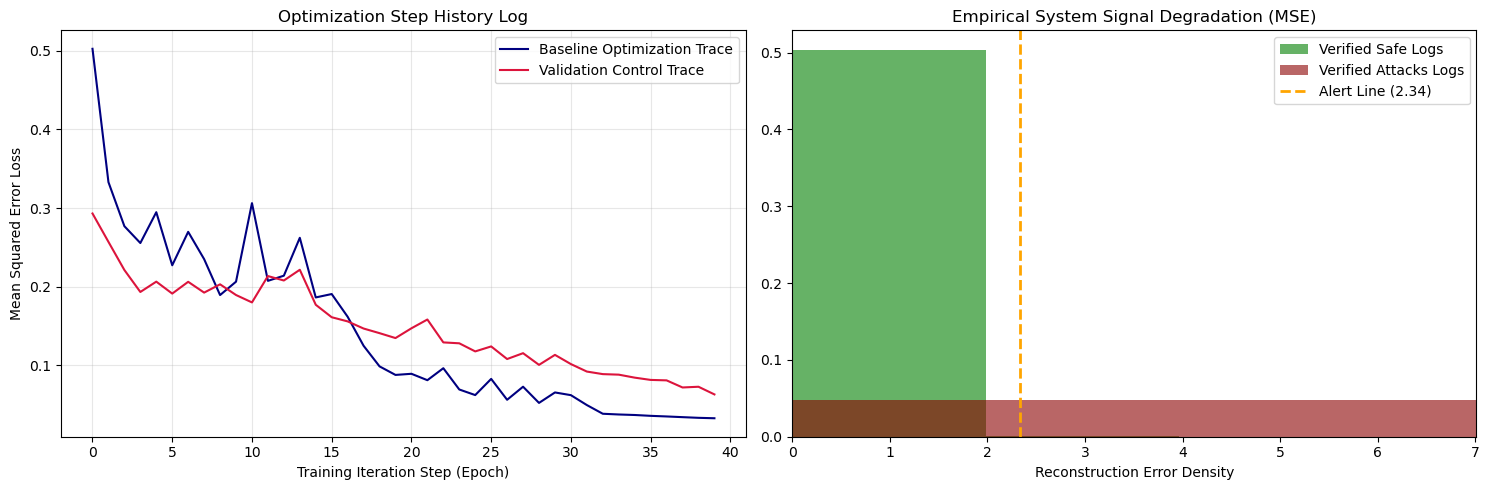

In [11]:
# Cell 9: Core Visual Diagnostic Metrics
plt.figure(figsize=(15, 5))

# Plot 1: Optimization loss behavior
plt.subplot(1, 2, 1)
plt.plot(training_metrics.history['loss'], label='Baseline Optimization Trace', color='navy')
plt.plot(training_metrics.history['val_loss'], label='Validation Control Trace', color='crimson')
plt.title('Optimization Step History Log')
plt.xlabel('Training Iteration Step (Epoch)')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Empirical Error Distribution Configurations
plt.subplot(1, 2, 2)
plt.hist(test_error_profiles[y_test == 0], bins=50, alpha=0.6, color='emerald' if 'emerald' in plt.colormaps() else 'green', label='Verified Safe Logs', density=True)
plt.hist(test_error_profiles[y_test == 1], bins=50, alpha=0.6, color='darkred', label='Verified Attacks Logs', density=True)
plt.axvline(detection_boundary, color='orange', linestyle='--', linewidth=2, label=f'Alert Line ({detection_boundary:.2f})')
plt.title('Empirical System Signal Degradation (MSE)')
plt.xlabel('Reconstruction Error Density')
plt.legend()
plt.xlim(0, detection_boundary * 3)
plt.tight_layout()
plt.show()

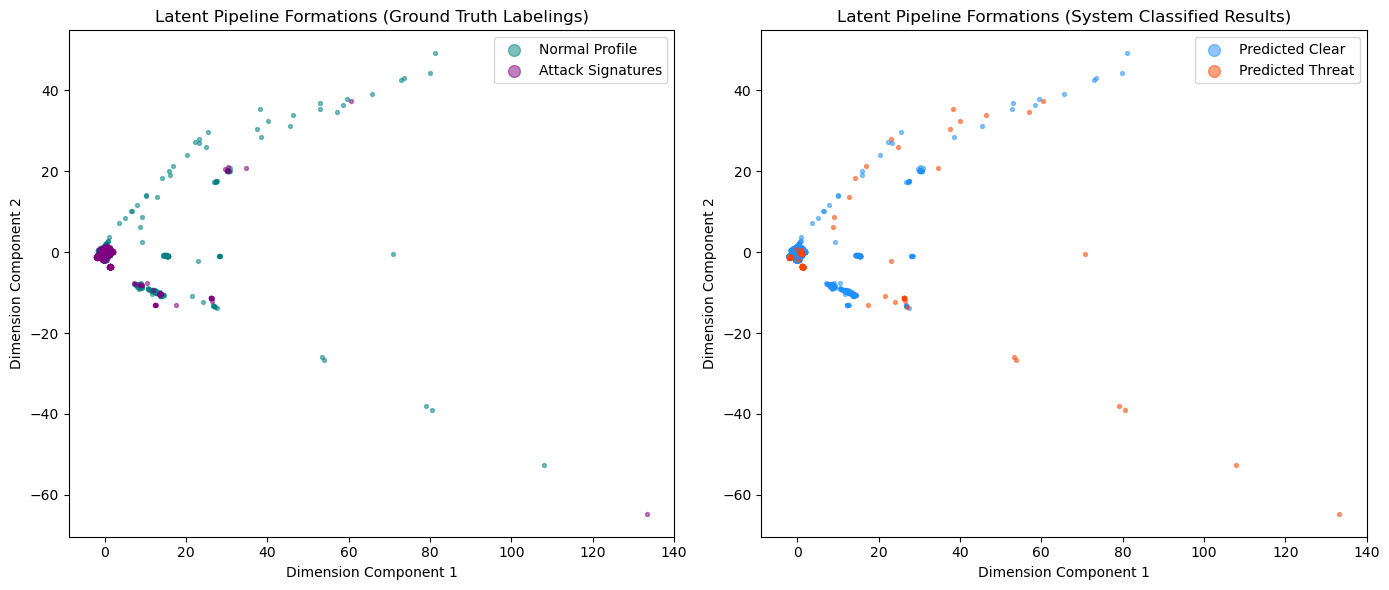

In [12]:
# Cell 10: Dimensional Compression & Latent Space Layouts
dimensionality_reducer = PCA(n_components=2)
reduced_2d_projections = dimensionality_reducer.fit_transform(test_latent_projections)

plt.figure(figsize=(14, 6))

# Plot A: Ground Truth Distributions
plt.subplot(1, 2, 1)
plt.scatter(reduced_2d_projections[y_test == 0, 0], reduced_2d_projections[y_test == 0, 1], c='teal', alpha=0.5, s=8, label='Normal Profile')
plt.scatter(reduced_2d_projections[y_test == 1, 0], reduced_2d_projections[y_test == 1, 1], c='purple', alpha=0.5, s=8, label='Attack Signatures')
plt.title('Latent Pipeline Formations (Ground Truth Labelings)')
plt.xlabel('Dimension Component 1')
plt.ylabel('Dimension Component 2')
plt.legend(markerscale=3)

# Plot B: System Decision Allocations
plt.subplot(1, 2, 2)
plt.scatter(reduced_2d_projections[system_predictions == 0, 0], reduced_2d_projections[system_predictions == 0, 1], c='dodgerblue', alpha=0.5, s=8, label='Predicted Clear')
plt.scatter(reduced_2d_projections[system_predictions == 1, 0], reduced_2d_projections[system_predictions == 1, 1], c='orangered', alpha=0.5, s=8, label='Predicted Threat')
plt.title('Latent Pipeline Formations (System Classified Results)')
plt.xlabel('Dimension Component 1')
plt.ylabel('Dimension Component 2')
plt.legend(markerscale=3)

plt.tight_layout()
plt.show()